## This is the script for all the EDA code for our dataset. It aims to provide insight into trends of the variables over time, as well as answer our initial questions about the dataset.

In [ ]:
# importing data

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df = pd.read_csv(
    "CA_Weather_Fire_Dataset_1984-2025.csv",
    engine="python",
    on_bad_lines="warn"
)
df

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14983,2025-01-08,0.0,73.0,53.0,10.51,False,2025,20.0,0.143973,1,Winter,0.0,6.485714,8
14984,2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9
14985,2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10
14986,2025-01-11,0.0,66.0,46.0,NaN,False,2025,20.0,NaN,1,Winter,0.0,6.561667,11


In [ ]:
# data quality check

df.isnull().sum()

,0
DATE,0
PRECIPITATION,1
MAX_TEMP,1
MIN_TEMP,1
AVG_WIND_SPEED,12
FIRE_START_DAY,0
YEAR,0
TEMP_RANGE,1
WIND_TEMP_RATIO,12
MONTH,0


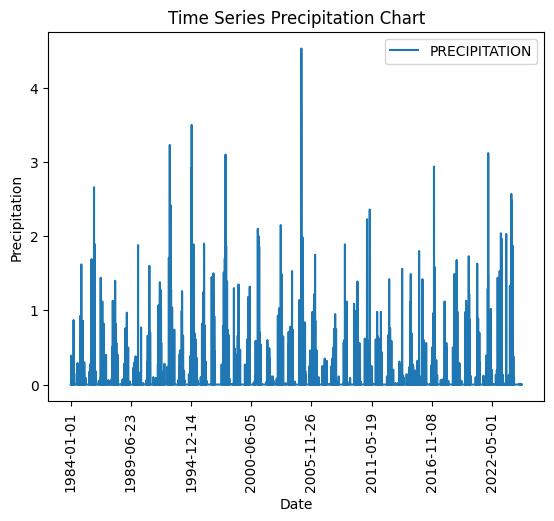

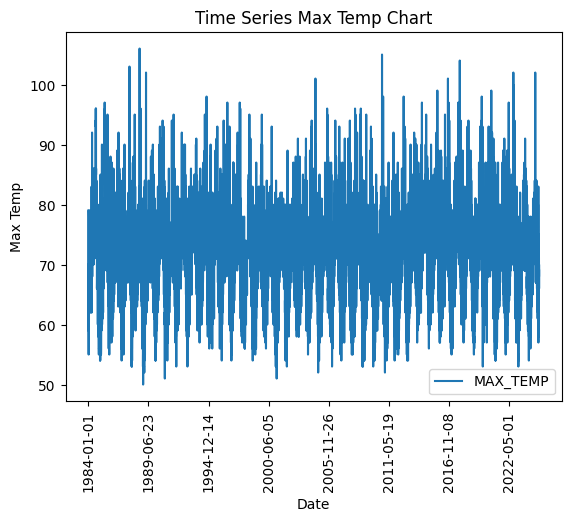

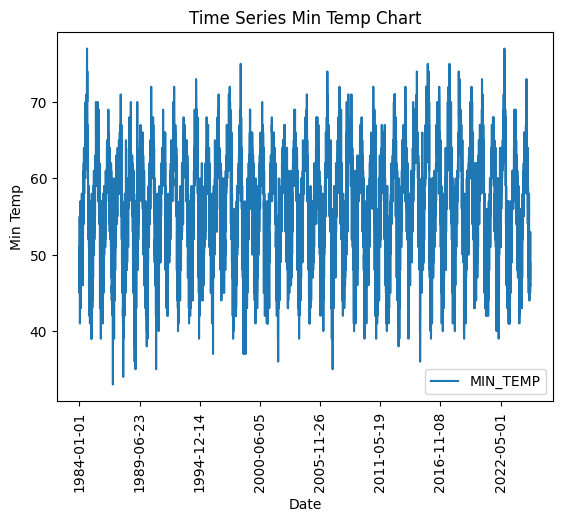

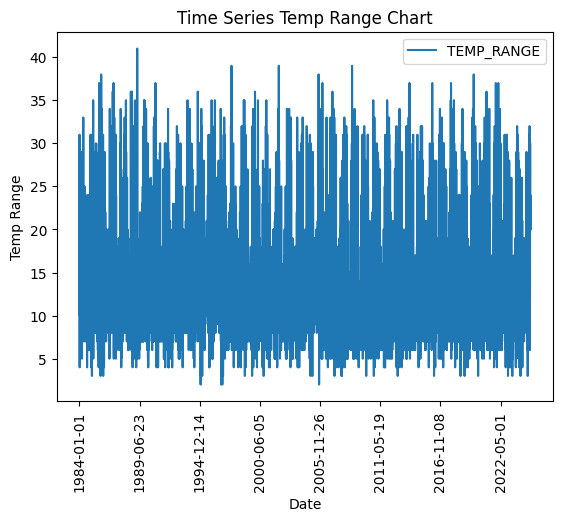

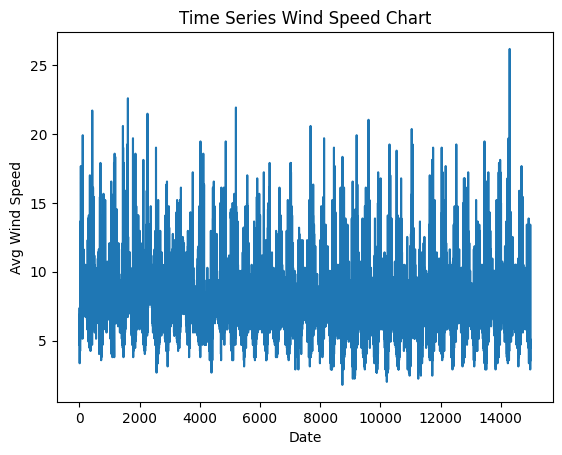

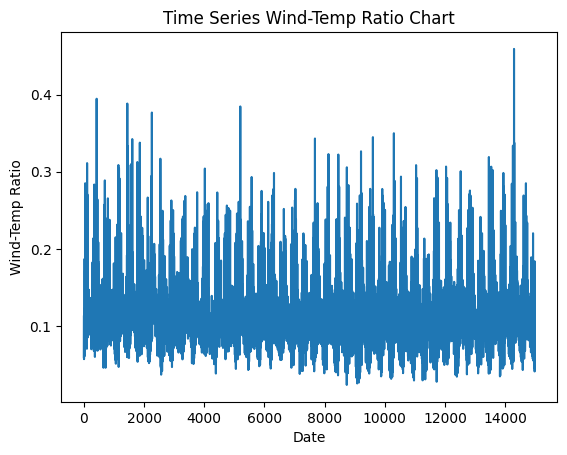

In [ ]:
# line chart time series of each variable

df.plot(x='DATE', y='PRECIPITATION', kind='line', title='Time Series Precipitation Chart')
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.xticks(rotation=90)
plt.show()

df.plot(x='DATE', y='MAX_TEMP', kind='line', title='Time Series Max Temp Chart')
plt.xlabel('Date')
plt.ylabel('Max Temp')
plt.xticks(rotation=90)
plt.show()

df.plot(x='DATE', y='MIN_TEMP', kind='line', title='Time Series Min Temp Chart')
plt.xlabel('Date')
plt.ylabel('Min Temp')
plt.xticks(rotation=90)
plt.show()

df.plot(x='DATE', y='TEMP_RANGE', kind='line', title='Time Series Temp Range Chart')
plt.xlabel('Date')
plt.ylabel('Temp Range')
plt.xticks(rotation=90)
plt.show()

df['AVG_WIND_SPEED'].plot(kind='line', title='Time Series Wind Speed Chart')
plt.xlabel('Date')
plt.ylabel('Avg Wind Speed')
plt.show()

df['WIND_TEMP_RATIO'].plot(kind='line', title='Time Series Wind-Temp Ratio Chart')
plt.xlabel('Date')
plt.ylabel('Wind-Temp Ratio')
plt.show()

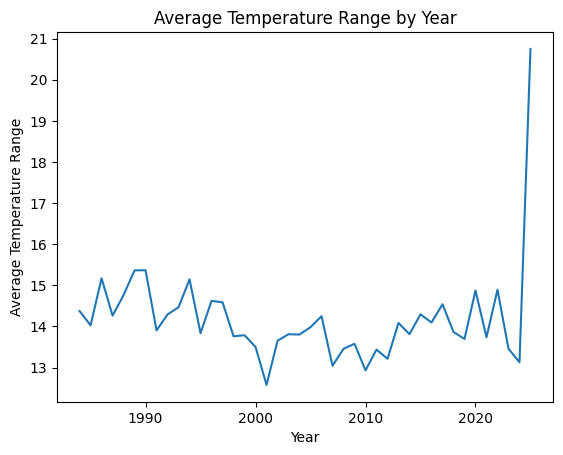

In [ ]:
# average temp range by year to see what changes

avg_temp_range = df.groupby('YEAR')['TEMP_RANGE'].mean()
avg_temp_range.plot(kind='line')

plt.xlabel('Year')
plt.ylabel('Average Temperature Range')
plt.title('Average Temperature Range by Year')

plt.show()

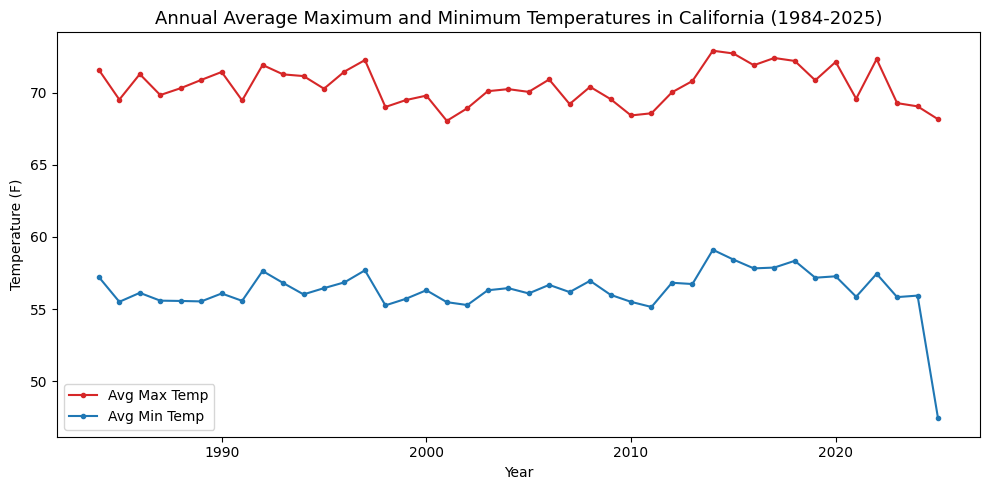

Saved: fig_temp_trends.png


In [ ]:
# annual average MAX_TEMP and MIN_TEMP trends over time
# computes annual averages to smooth day-to-day noise

annual_temp = df.groupby("YEAR")[["MAX_TEMP", "MIN_TEMP"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(annual_temp["YEAR"], annual_temp["MAX_TEMP"], label="Avg Max Temp", marker="o",
        markersize=3, linewidth=1.5, color="#d62728")
ax.plot(annual_temp["YEAR"], annual_temp["MIN_TEMP"], label="Avg Min Temp", marker="o",
        markersize=3, linewidth=1.5, color="#1f77b4")
ax.set_title("Annual Average Maximum and Minimum Temperatures in California (1984-2025)",
             fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (F)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_temp_trends.png", dpi=150)
plt.show()
print("Saved: fig_temp_trends.png")

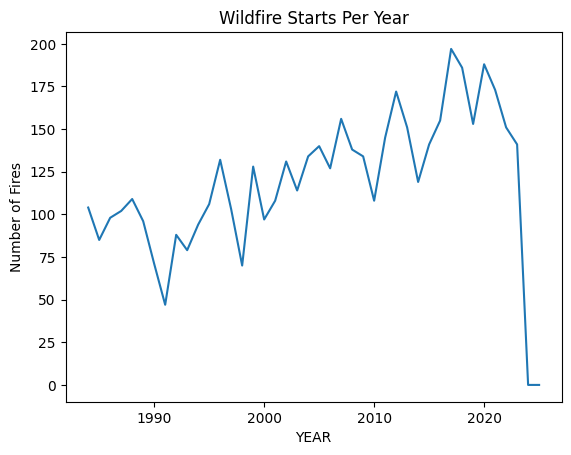

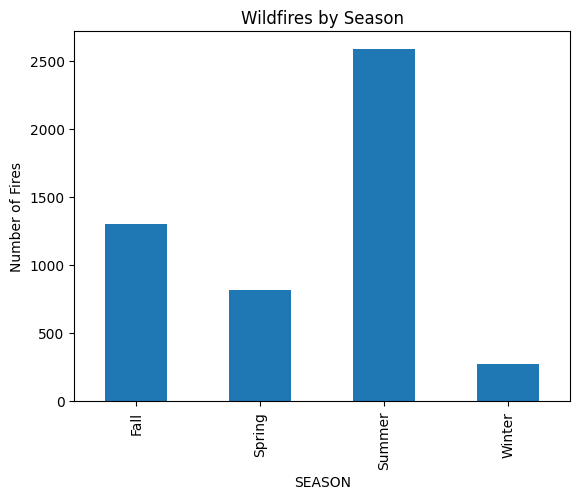

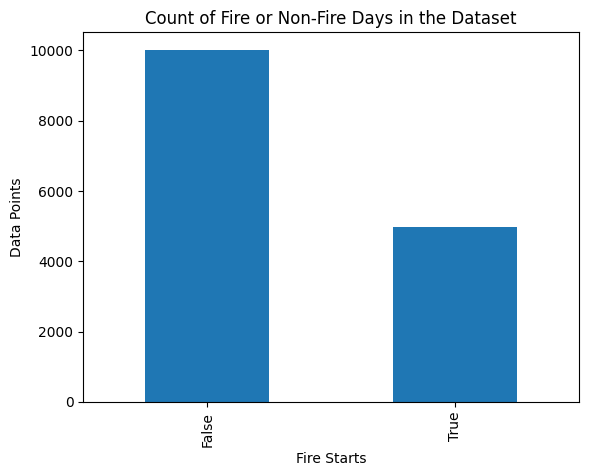

In [ ]:
# average number of fires per year

fires_per_year = df.groupby('YEAR')['FIRE_START_DAY'].sum()

fires_per_year.plot(kind='line', title='Wildfire Starts Per Year')
plt.ylabel('Number of Fires')
plt.show()

# bar chart of wildfires by season
# SEASON column contains string labels: Fall, Spring, Summer, Winter

df.groupby('SEASON')['FIRE_START_DAY'].sum().plot(kind='bar',
                                                   title='Wildfires by Season')
plt.ylabel('Number of Fires')
plt.show()

# bar chart of how many fire vs non-fire days

df['FIRE_START_DAY'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Fire Starts')
plt.ylabel('Data Points')
plt.title('Count of Fire or Non-Fire Days in the Dataset')
plt.show()

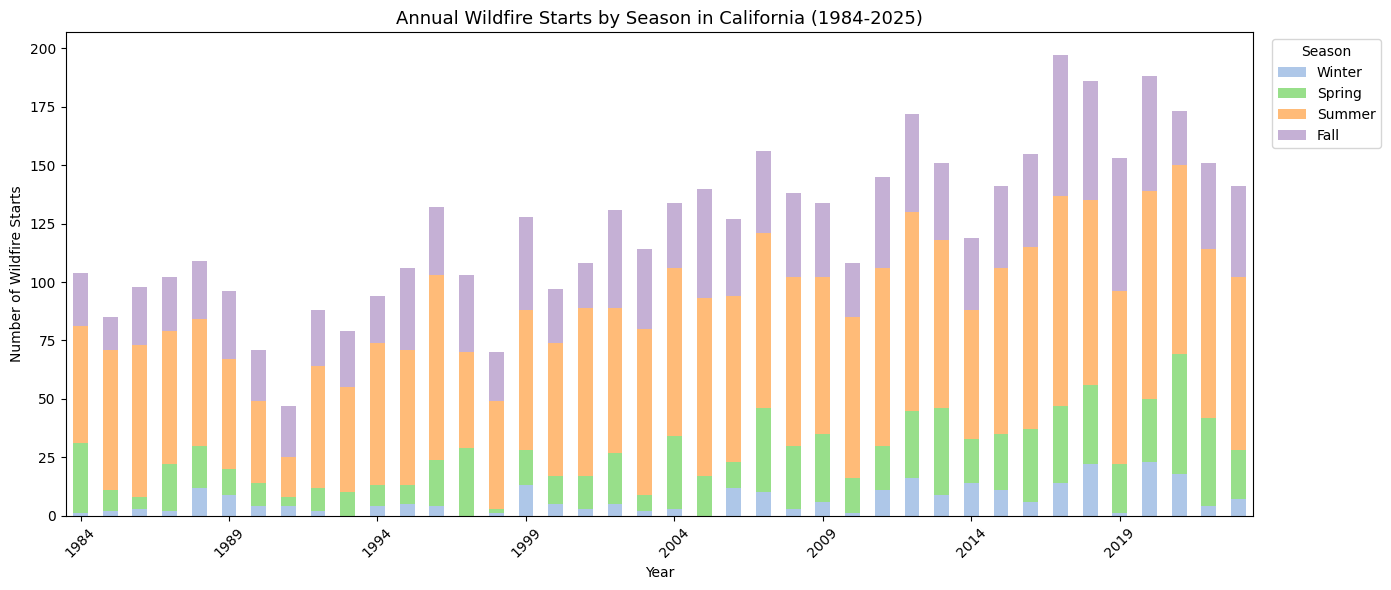

Saved: fig_fires_by_season_year.png


In [ ]:
# wildfire counts by season per year (stacked bar) to show change over time

fires_only = df[df["FIRE_START_DAY"] == True]
season_order = ["Winter", "Spring", "Summer", "Fall"]

fires_season_year = (fires_only.groupby(["YEAR", "SEASON"])
                                .size()
                                .unstack(fill_value=0)
                                .reindex(columns=season_order, fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
fires_season_year.plot(kind="bar", stacked=True, ax=ax,
                       color=["#aec7e8", "#98df8a", "#ffbb78", "#c5b0d5"])
ax.set_title("Annual Wildfire Starts by Season in California (1984-2025)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Wildfire Starts")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_tick_params(rotation=45)
ax.legend(title="Season", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig_fires_by_season_year.png", dpi=150)
plt.show()
print("Saved: fig_fires_by_season_year.png")

In [ ]:
# how many fires started by year in the dataset

df.sort_values('DATE')
wildfires_per_year = df.groupby('YEAR')['FIRE_START_DAY'].sum()
wildfires_per_year.sort_values()

,FIRE_START_DAY
YEAR,
2024,0
2025,0
1991,47
1998,70
1990,71
1993,79
1985,85
1992,88
1994,94


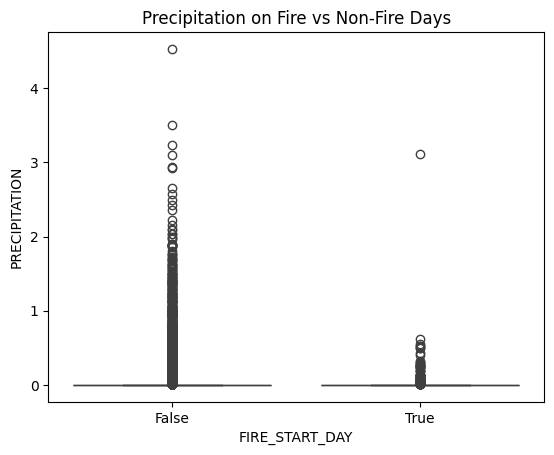

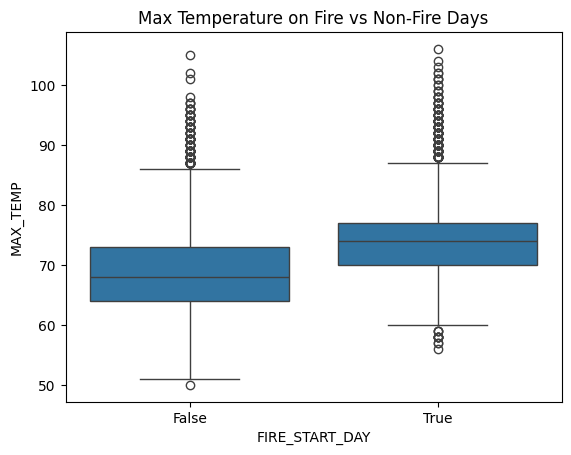

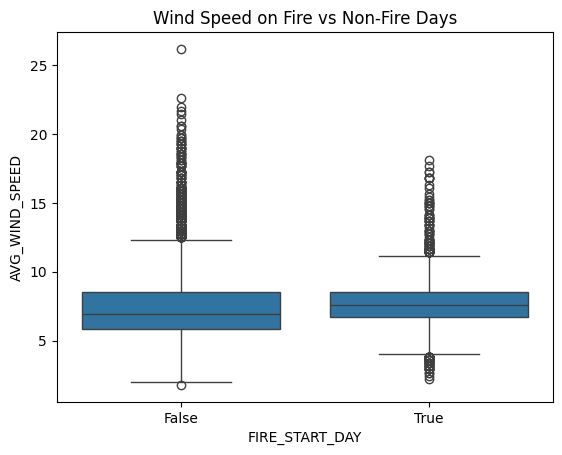

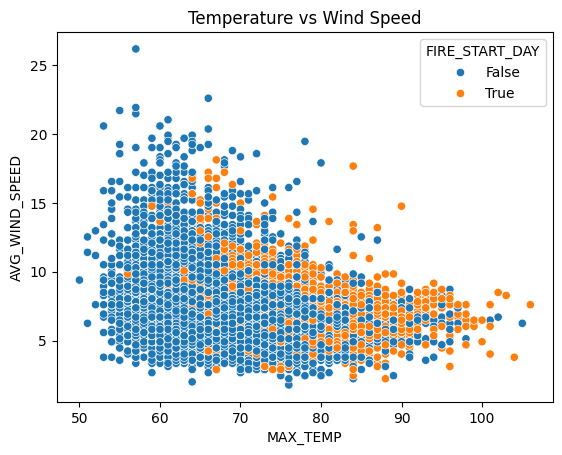

In [ ]:
# boxplot of the average precipitation on fire vs non-fire days

sns.boxplot(x='FIRE_START_DAY', y='PRECIPITATION', data=df)
plt.title('Precipitation on Fire vs Non-Fire Days')
plt.show()

# boxplot of the average max temp on fire vs non-fire days

sns.boxplot(x='FIRE_START_DAY', y='MAX_TEMP', data=df)
plt.title('Max Temperature on Fire vs Non-Fire Days')
plt.show()

# boxplot of the average wind speed on fire vs non-fire days

sns.boxplot(x='FIRE_START_DAY', y='AVG_WIND_SPEED', data=df)
plt.title('Wind Speed on Fire vs Non-Fire Days')
plt.show()

# temperature vs wind speed chart based on fire or no fire

sns.scatterplot(data=df,
                x='MAX_TEMP',
                y='AVG_WIND_SPEED',
                hue='FIRE_START_DAY')
plt.title('Temperature vs Wind Speed')
plt.show()

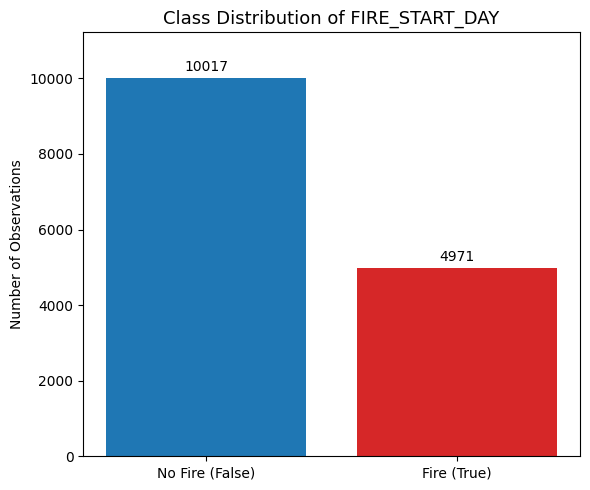

Saved: fig_class_imbalance.png


In [ ]:
# class imbalance in FIRE_START_DAY

class_counts = df["FIRE_START_DAY"].value_counts()
labels = ["No Fire (False)", "Fire (True)"]
values = [class_counts.get(False, 0), class_counts.get(True, 0)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, values, color=["#1f77b4", "#d62728"])
ax.bar_label(bars, padding=3, fmt="%d")
ax.set_title("Class Distribution of FIRE_START_DAY", fontsize=13)
ax.set_ylabel("Number of Observations")
total = sum(values)
ax.set_ylim(0, max(values) * 1.12)
plt.tight_layout()
plt.savefig("fig_class_imbalance.png", dpi=150)
plt.show()
print("Saved: fig_class_imbalance.png")

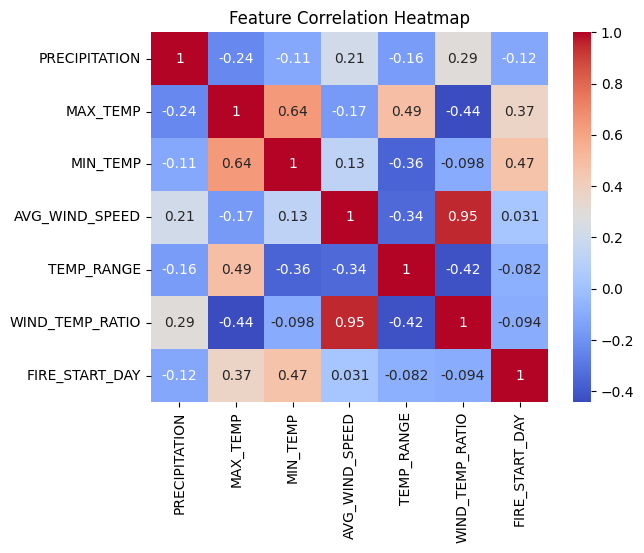

In [ ]:
# correlation chart of all variables

corr = df[['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
           'TEMP_RANGE', 'WIND_TEMP_RATIO', 'FIRE_START_DAY']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

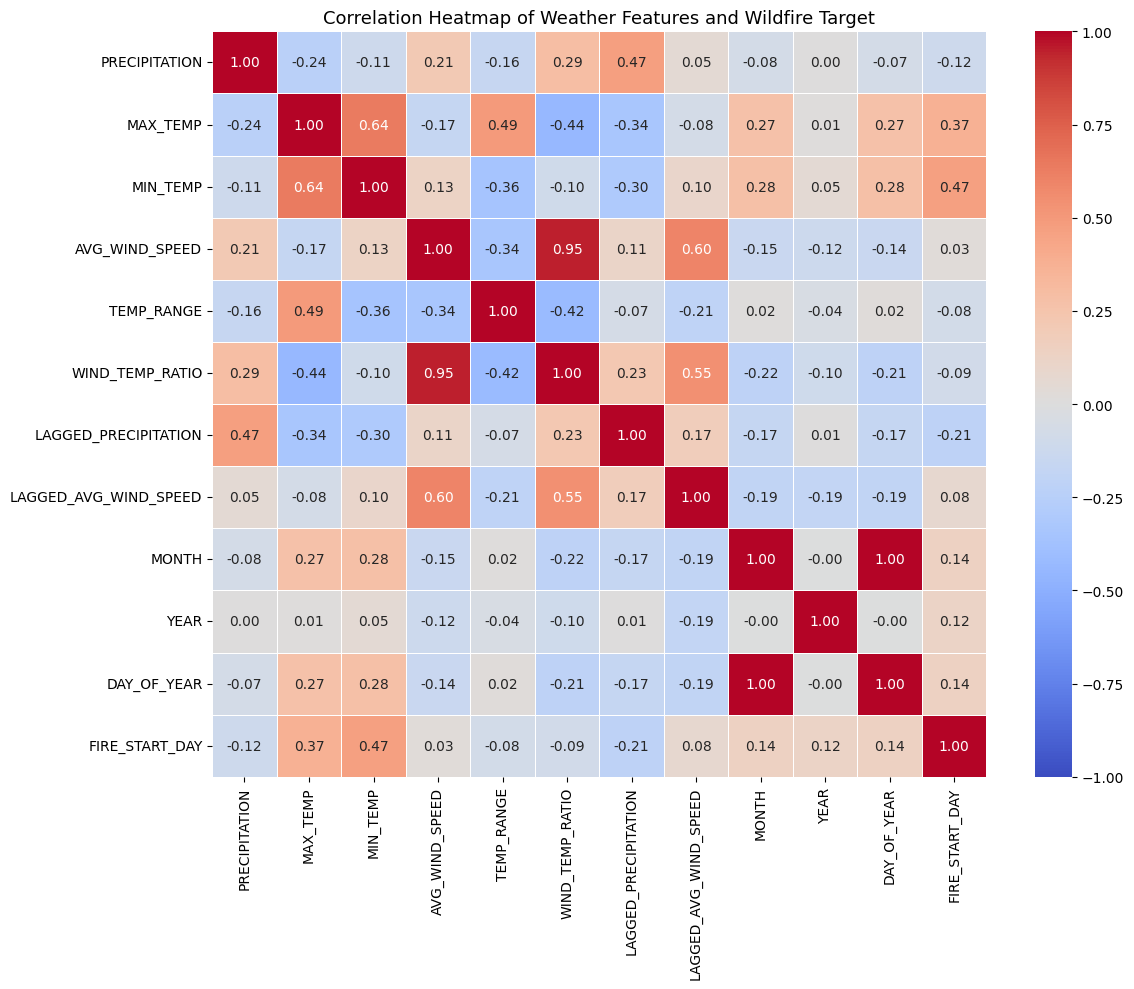

Saved: fig_correlation_heatmap.png


In [ ]:
# extended correlation heatmap including lagged features and time variables

numeric_cols = ["PRECIPITATION", "MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED",
                "TEMP_RANGE", "WIND_TEMP_RATIO", "LAGGED_PRECIPITATION",
                "LAGGED_AVG_WIND_SPEED", "MONTH", "YEAR", "DAY_OF_YEAR", "FIRE_START_DAY"]
corr_full = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap of Weather Features and Wildfire Target", fontsize=13)
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: fig_correlation_heatmap.png")

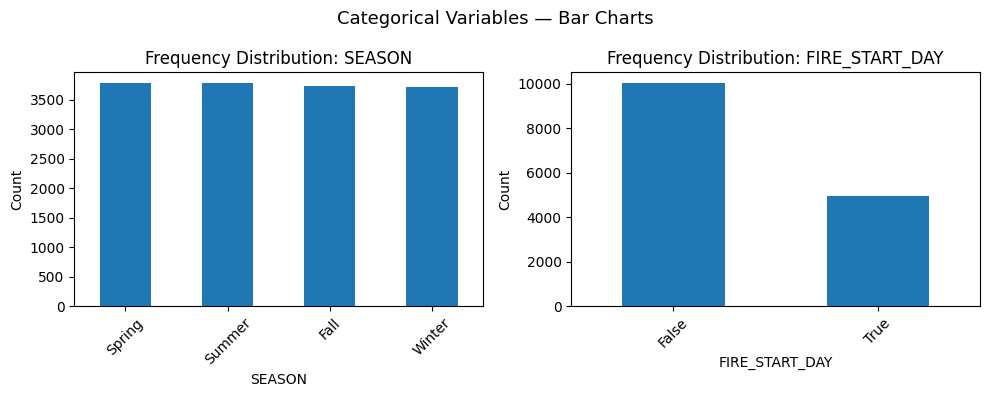

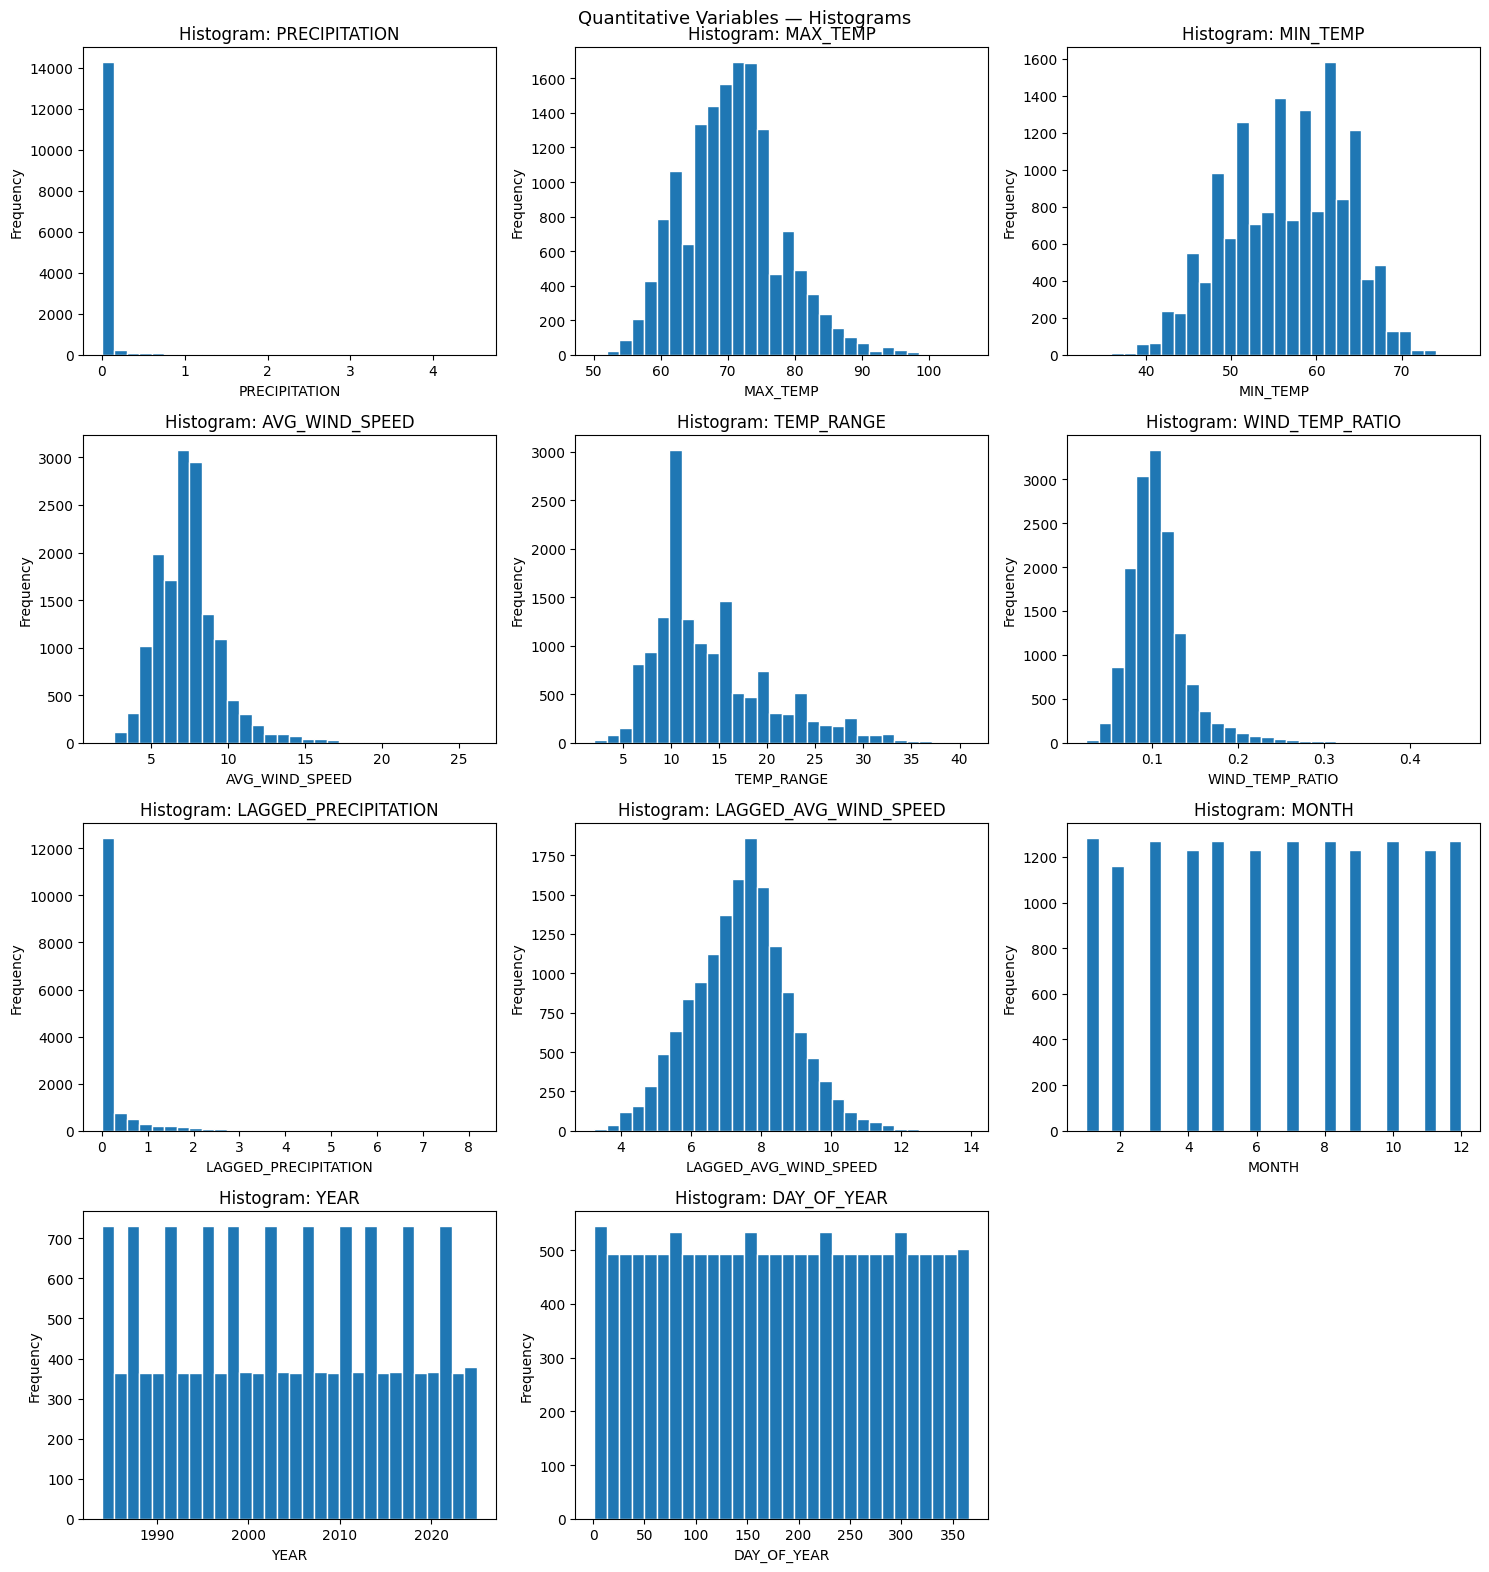

In [23]:
# visualizations of all variable distributions

import math

# Categorical variables
categorical_cols = ['SEASON', 'FIRE_START_DAY']

# Quantitative variables
quantitative_cols = ['PRECIPITATION', 'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPEED',
                     'TEMP_RANGE', 'WIND_TEMP_RATIO', 'LAGGED_PRECIPITATION',
                     'LAGGED_AVG_WIND_SPEED', 'MONTH', 'YEAR', 'DAY_OF_YEAR']

# --- Bar charts for categorical variables ---
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(10, 4))
for ax, col in zip(axes, categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Frequency Distribution: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Variables — Bar Charts', fontsize=13)
plt.tight_layout()
plt.show()

# --- Histograms for quantitative variables ---
n_cols = 3
n_rows = math.ceil(len(quantitative_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(quantitative_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='white')
    axes[i].set_title(f'Histogram: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Quantitative Variables — Histograms', fontsize=13)
plt.tight_layout()
plt.show()